# Prototyping Difference Gradient Analysis for MISalign 2.0

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as colors

In [8]:
# %matplotlib widget
%matplotlib inline

In [4]:
from misalign.model.project import MISProjectJSON
from misalign.model.relation import MISRelationRectangular
import misalign.alignment.difference_gradient as dga
import misalign.canvas.canvas_rectangular as cr

In [5]:
mis_filepath="../example/project_a/project_a-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)
print(mis_project)

A misalign project with:
Images:
    image_a01.jpg
    image_a02.jpg
    image_a03.jpg
    image_a04.jpg
    image_a05.jpg
    image_a06.jpg
    image_a07.jpg
    image_a08.jpg
    image_a09.jpg
    image_a10.jpg
Relations:
    ('image_a01.jpg', 'image_a02.jpg')
    ('image_a02.jpg', 'image_a03.jpg')
    ('image_a03.jpg', 'image_a04.jpg')
    ('image_a04.jpg', 'image_a05.jpg')
    ('image_a05.jpg', 'image_a06.jpg')
    ('image_a06.jpg', 'image_a07.jpg')
    ('image_a07.jpg', 'image_a08.jpg')
    ('image_a08.jpg', 'image_a09.jpg')
    ('image_a09.jpg', 'image_a10.jpg')
Calibration:
    pixel : 600
    length : 1
    length_unit : mm
Project Path:
    ..\example\project_a\project_a-relations-calibrated.mis.json


In [9]:
plt.close('all')

In [6]:
# 2 is fairly well overlapped
# 7 is neat for seeing how physical features effect plot.
# 8 is particularly bad initial alignment and good for visualizing
selected_relation=mis_project.get_relations()[8]
selected_dga_results=dga.difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        relation=selected_relation,
        strategy=dga.strategy_scaled_grid,
        metric=dga.metric_squared_mean,
        strategy_max_size=10,
        strategy_grid_scale=1,
        filter=dga.filter_rgb_gray
        )
print("Initial:",selected_dga_results["initial_offset"],"Optimized:",selected_dga_results["optimized_offset"])

Initial: (3, -722) Optimized: (4, -715)


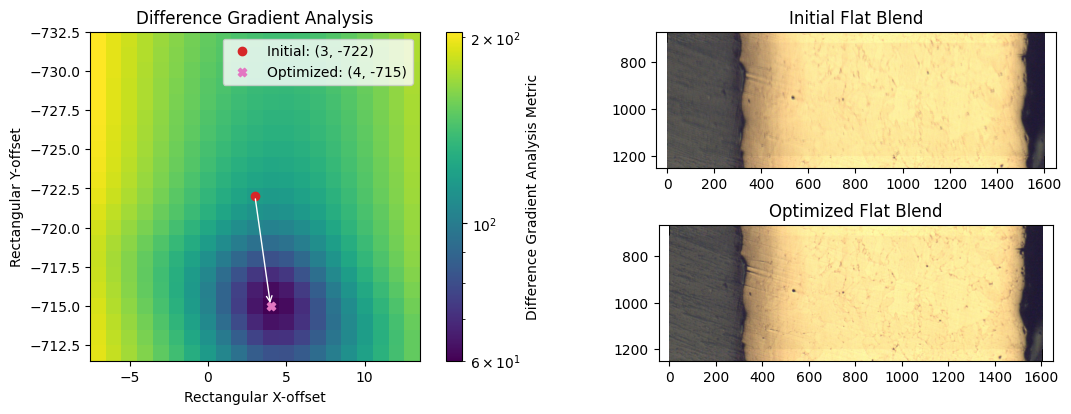

In [10]:
dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        dga_grid_result=selected_dga_results,
    )
plt.show()

0 : ('image_a01.jpg', 'image_a02.jpg') (12, -1088) -> (9, -1087)


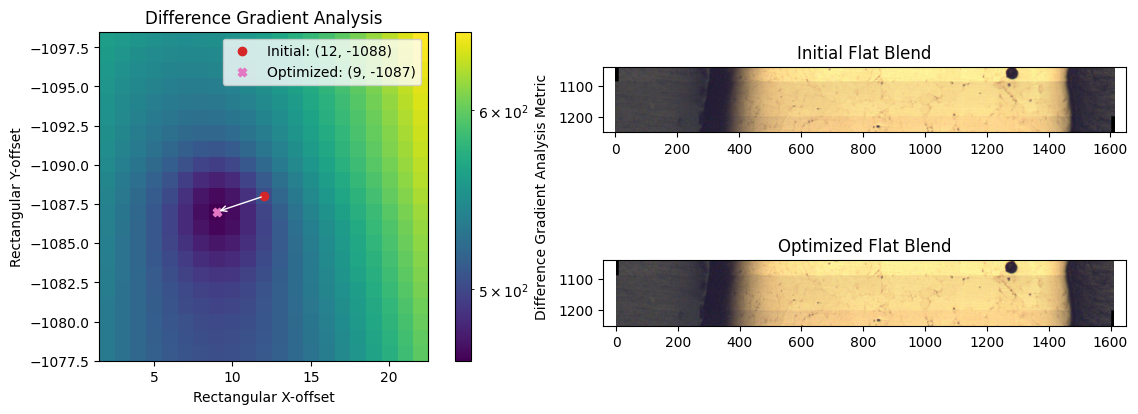

1 : ('image_a02.jpg', 'image_a03.jpg') (8, -1141) -> (8, -1146)


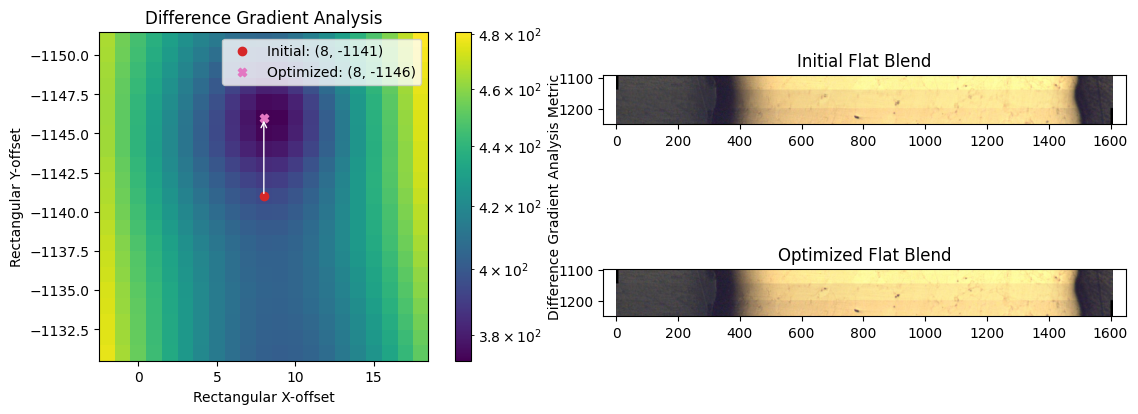

2 : ('image_a03.jpg', 'image_a04.jpg') (-129, -1058) -> (-124, -1060)


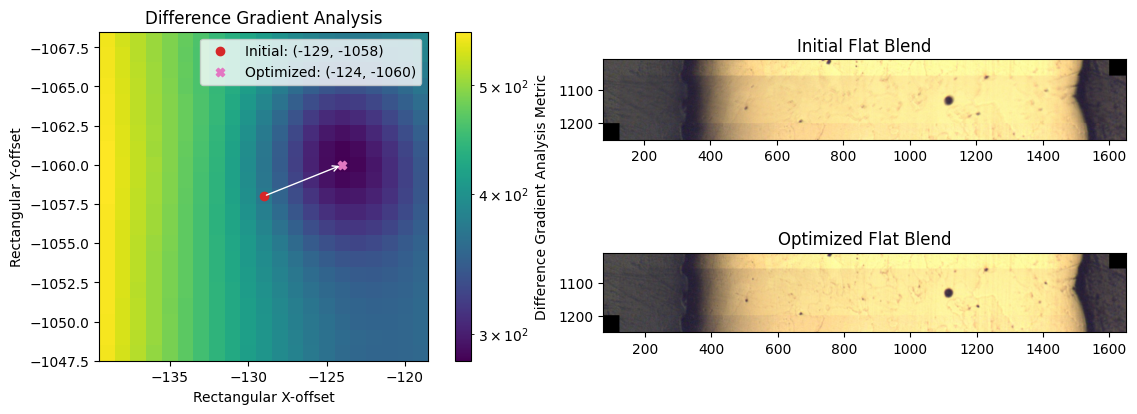

3 : ('image_a04.jpg', 'image_a05.jpg') (11, -943) -> (10, -942)


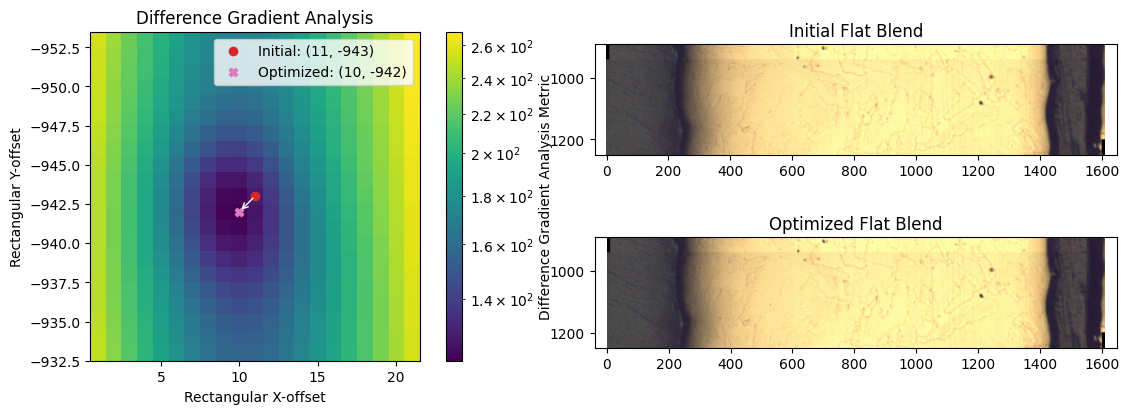

4 : ('image_a05.jpg', 'image_a06.jpg') (5, -860) -> (7, -857)


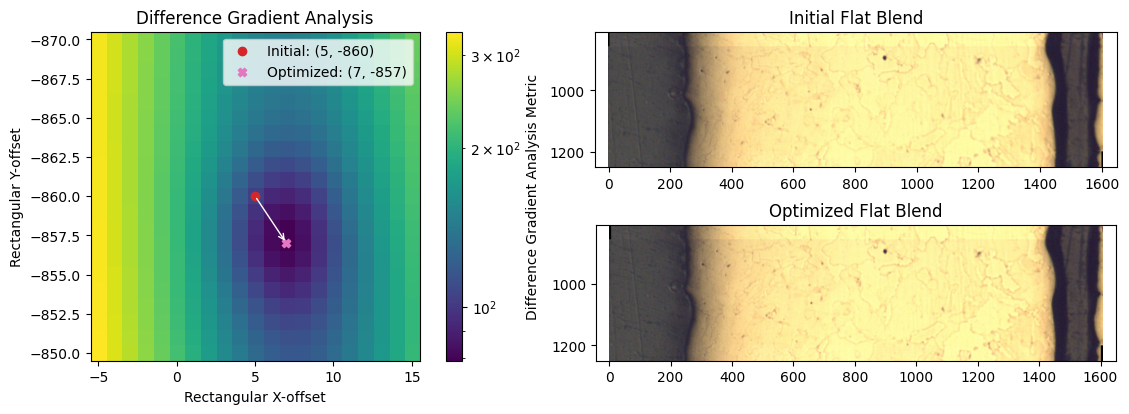

5 : ('image_a06.jpg', 'image_a07.jpg') (10, -990) -> (8, -989)


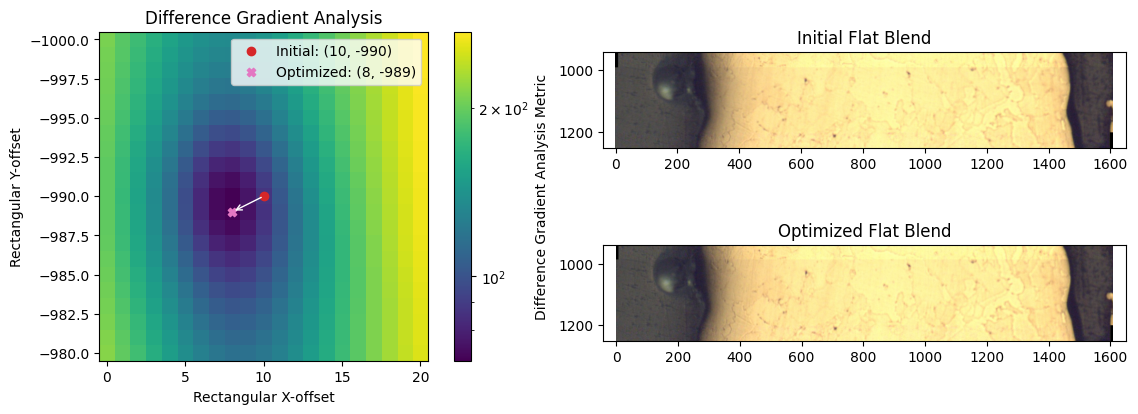

6 : ('image_a07.jpg', 'image_a08.jpg') (9, -1009) -> (8, -1008)


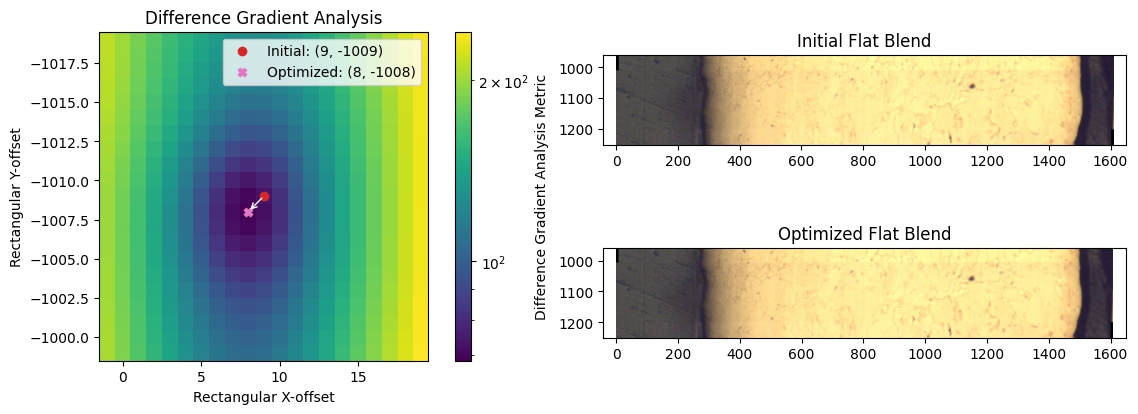

7 : ('image_a08.jpg', 'image_a09.jpg') (9, -939) -> (8, -938)


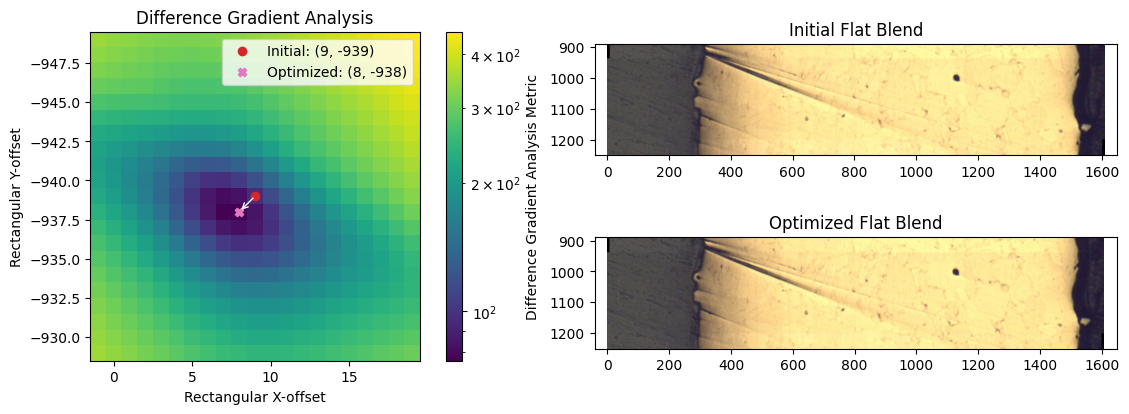

8 : ('image_a09.jpg', 'image_a10.jpg') (3, -722) -> (4, -715)


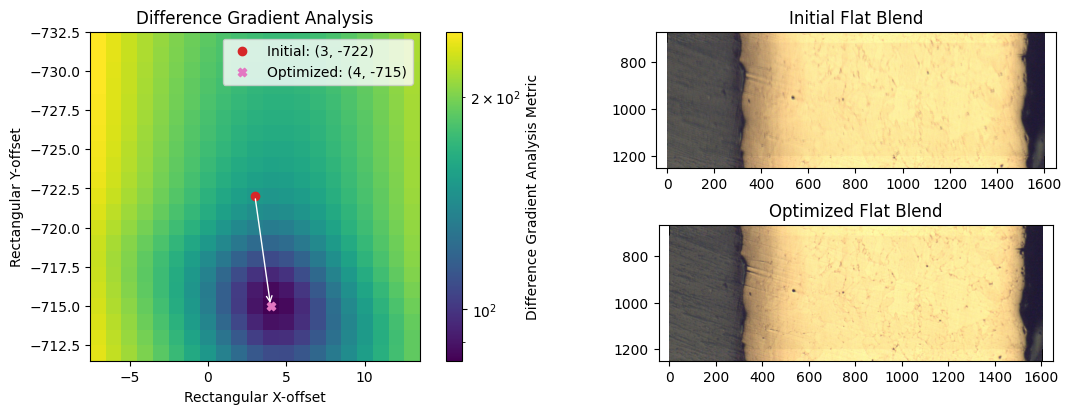

In [11]:
relation_index_results=dict()
for i,relation in enumerate(mis_project.get_relations()):
    dga_results=dga.difference_gradient_analysis(
            image_a=mis_project.get_image(relation.get_reference()[0]),
            image_b=mis_project.get_image(relation.get_reference()[1]),
            relation=relation,
            strategy=dga.strategy_full_grid,
            metric=dga.metric_squared_mean,
            strategy_max_size=10,
            )
    print(i,":",relation.get_reference(),relation.get_relation('r'),"->",dga_results["optimized_offset"])
    dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(relation.get_reference()[0]),
        image_b=mis_project.get_image(relation.get_reference()[1]),
        dga_grid_result=dga_results,
    )
    plt.show()
    

In [ ]:
# [mis_project.set_relation(i,relation) for i,relation in relation_index_results.items()]
# mis_filepath="../example/project_a/project_a-dga_relations-calibrated.mis.json"
# mis_project.save(mis_filepath)

# Comparing Performances

In [ ]:
# Using `mis_project.get_relations()[1]` which has an ideal offset of `(8, -1146)`
# We can check strategy_max_size=50 which gives 101x101=10201 offsets.
# Not including plotting the cell takes 7.3s to run.
# Using `mis_project.get_relations()[2]` which has an ideal offset of `(-124, -1060)`
# strategy_max_size=50 which gives 201x201=40401 > Not including plotting takes 16.9s to run.
    # 16.9s using np.int32 / 12.5s using np.int16
# strategy_max_size=100 which gives 201x201=40401 > Not including plotting takes 67.3s to run.
# In general: Higher overlap takes more time, strategy size has squared relationship with run time.

# Trying out filters:
    # with `dga.metric_squared_mean`
        # `mis_project.get_relations()[2]` > `strategy_max_size=50` > `filter=filter_rgb_gray` > 3.2s
        # `mis_project.get_relations()[2]` > `strategy_max_size=100` > no filter > 48.3s
        # `mis_project.get_relations()[2]` > `strategy_max_size=100` > `filter=filter_rgb_gray` > 15.4s
        # `mis_project.get_relations()[2]` > `strategy_max_size=100` > `filter=filter_rgb_gray_reduced` > 12.2s
            # return np.sqrt(np.mean(image,axis=-1)).astype(np.uint8) > Not worth the added complexity.
    # with `dga.metric_absolute_mean`
        # `mis_project.get_relations()[2]` > `strategy_max_size=100` > no filter > 50.9s
        # `mis_project.get_relations()[2]` > `strategy_max_size=100` > `filter=filter_rgb_gray` > 12.9s

# Note: time is fairly variable run-to-run
    # Should implement performance timing

In [26]:
import timeit
import pandas as pd
import seaborn as sns
import math

In [31]:
# 2 is fairly well overlapped
# 8 is extremely well overlapped
performance_relation=mis_project.get_relations()[2]
performance_optimized_relation=(-124, -1060) # for [2]
performance_dga_results=dga.difference_gradient_analysis(
        image_a=mis_project.get_image(performance_relation.get_reference()[0]),
        image_b=mis_project.get_image(performance_relation.get_reference()[1]),
        relation=performance_relation,
        strategy=dga.strategy_scaled_grid,
        metric=dga.metric_squared_mean,
        strategy_max_size=20,
        strategy_grid_scale=1,
        filter=dga.filter_rgb_gray
        )
print("Initial:",performance_dga_results["initial_offset"],"Optimized:",performance_dga_results["optimized_offset"])
def performance_run(kwargs):
    performance_dga_results=dga.difference_gradient_analysis(
        image_a=mis_project.get_image(performance_relation.get_reference()[0]),
        image_b=mis_project.get_image(performance_relation.get_reference()[1]),
        relation=performance_relation,
        **kwargs
        )
    # assert performance_dga_results["optimized_offset"]==performance_optimized_relation # this makes sure that the same result is found
    assert math.dist(performance_dga_results["optimized_offset"],performance_optimized_relation)<2 # this makes sure that the result is identical or neighbor to reference.
def get_run_description(kwargs)->dict:
    return {key:(value.__name__ if hasattr(value,"__name__") else value) for key,value in kwargs.items()}
performance_repeats=5
performance_repeats_long=1
performance_results=list()

Initial: (-129, -1058) Optimized: (-124, -1060)


In [ ]:
for size in [20,50]:
    kwargs=dict(
        strategy=dga.strategy_full_grid,
        metric=dga.metric_squared_mean,
        strategy_max_size=size,
        filter=dga.filter_simple
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)

for size in [20,50,100]:
    kwargs=dict(
        strategy=dga.strategy_full_grid,
        metric=dga.metric_squared_mean,
        strategy_max_size=size,
        filter=dga.filter_rgb_gray
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)

{'strategy': 'strategy_full_grid', 'metric': 'metric_squared_mean', 'strategy_max_size': 20, 'filter': 'filter_simple', 'average_time': 2.1348210000000107}
{'strategy': 'strategy_full_grid', 'metric': 'metric_squared_mean', 'strategy_max_size': 20, 'filter': 'filter_rgb_gray', 'average_time': 0.5878788199999689}
{'strategy': 'strategy_full_grid', 'metric': 'metric_squared_mean', 'strategy_max_size': 50, 'filter': 'filter_rgb_gray', 'average_time': 3.2315231199998378}
{'strategy': 'strategy_full_grid', 'metric': 'metric_squared_mean', 'strategy_max_size': 100, 'filter': 'filter_rgb_gray', 'average_time': 12.13370415999998}


In [ ]:
for size in [20,50]:
    kwargs=dict(
        strategy=dga.strategy_full_grid,
        metric=dga.metric_absolute_mean,
        strategy_max_size=size,
        filter=dga.filter_simple
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)


for size in [20,50,100]:
    kwargs=dict(
        strategy=dga.strategy_full_grid,
        metric=dga.metric_absolute_mean,
        strategy_max_size=size,
        filter=dga.filter_rgb_gray
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)

{'strategy': 'strategy_full_grid', 'metric': 'metric_absolute_mean', 'strategy_max_size': 20, 'filter': 'filter_simple', 'average_time': 1.7796797800001514}
{'strategy': 'strategy_full_grid', 'metric': 'metric_absolute_mean', 'strategy_max_size': 20, 'filter': 'filter_rgb_gray', 'average_time': 0.5594103200000973}
{'strategy': 'strategy_full_grid', 'metric': 'metric_absolute_mean', 'strategy_max_size': 50, 'filter': 'filter_rgb_gray', 'average_time': 3.174082199999975}
{'strategy': 'strategy_full_grid', 'metric': 'metric_absolute_mean', 'strategy_max_size': 100, 'filter': 'filter_rgb_gray', 'average_time': 12.193833700000322}


In [ ]:
for size in [20,50]:
    kwargs=dict(
        strategy=dga.strategy_full_grid,
        metric=dga.metric_combined_balanced,
        strategy_max_size=size,
        filter=dga.filter_rgb_gray
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)

{'strategy': 'strategy_full_grid', 'metric': 'metric_combined_balanced', 'strategy_max_size': 20, 'filter': 'filter_rgb_gray', 'average_time': 3.481720860000132}
{'strategy': 'strategy_full_grid', 'metric': 'metric_combined_balanced', 'strategy_max_size': 50, 'filter': 'filter_rgb_gray', 'average_time': 20.65703788000028}


In [37]:
def metric_highlow_inverse_norm_test(overlap_a:np.ndarray,overlap_b:np.ndarray,modifier=64)->float:
    """High value when difference of maximum and minimum intensity of overlap region is low > weights against low-feature regions"""
    def metric(overlap):
        return  np.min([1/((np.max(overlap)-np.min(overlap))/modifier),1])
        # variation of 64 > value of 1 > variation of 128 > value of 1/2
    return np.max([metric(overlap_a),metric(overlap_b)])

def metric_custom(overlap_a:np.ndarray,overlap_b:np.ndarray):
    return np.sum([
        dga.metric_difference_max_norm(overlap_a,overlap_b),
        dga.metric_squared_mean_norm(overlap_a,overlap_b)**0.1,
        # dga.metric_highlow_inverse_norm(overlap_a,overlap_b),
        metric_highlow_inverse_norm_test(overlap_a,overlap_b),
    ])

for size in [20,50]:
    kwargs=dict(
        strategy=dga.strategy_full_grid,
        metric=metric_custom,
        strategy_max_size=size,
        filter=dga.filter_rgb_gray
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)

{'strategy': 'strategy_full_grid', 'metric': 'metric_custom', 'strategy_max_size': 20, 'filter': 'filter_rgb_gray', 'average_time': 1.1036930199999915}
{'strategy': 'strategy_full_grid', 'metric': 'metric_custom', 'strategy_max_size': 50, 'filter': 'filter_rgb_gray', 'average_time': 6.735009079999872}


In [ ]:
#TODO add total time(timeit call)/then average time

In [38]:
df_performance=pd.DataFrame(performance_results)
df_performance["average_time"]=np.round(df_performance["average_time"],2)
df_performance["total_checked"]=(2*df_performance["strategy_max_size"]+1)**2
print(df_performance.to_markdown())

|    | strategy           | metric                   |   strategy_max_size | filter          |   average_time |   total_checked |
|---:|:-------------------|:-------------------------|--------------------:|:----------------|---------------:|----------------:|
|  0 | strategy_full_grid | metric_squared_mean      |                  20 | filter_simple   |           2.13 |            1681 |
|  1 | strategy_full_grid | metric_squared_mean      |                  20 | filter_rgb_gray |           0.59 |            1681 |
|  2 | strategy_full_grid | metric_squared_mean      |                  50 | filter_rgb_gray |           3.23 |           10201 |
|  3 | strategy_full_grid | metric_squared_mean      |                 100 | filter_rgb_gray |          12.13 |           40401 |
|  4 | strategy_full_grid | metric_absolute_mean     |                  20 | filter_simple   |           1.78 |            1681 |
|  5 | strategy_full_grid | metric_absolute_mean     |                  20 | filter_rgb_gr

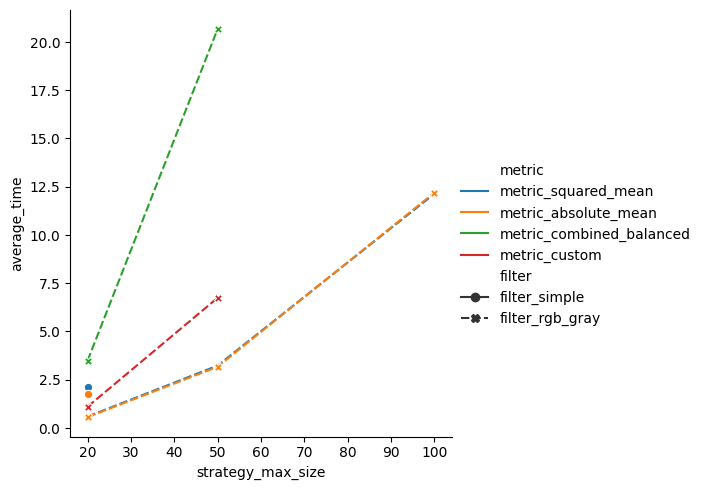

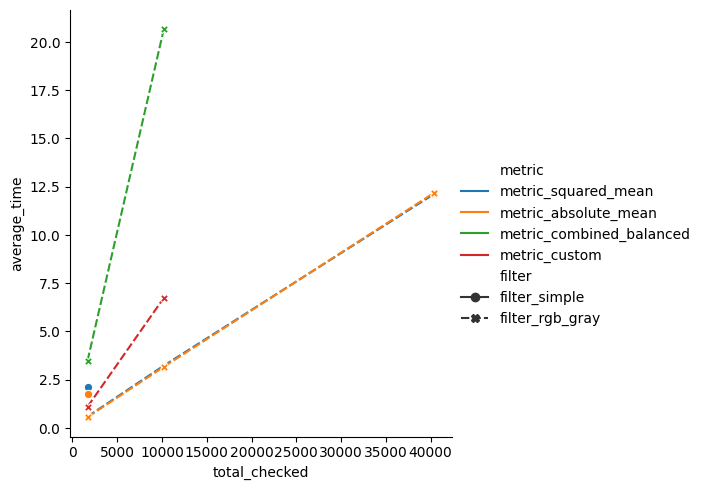

In [39]:
sns.relplot(
    data=df_performance,
    x='strategy_max_size',
    y='average_time',
    hue='metric',
    style='filter',
    markers=["o","X"],
    kind="line",
    )
sns.relplot(
    data=df_performance,
    x='total_checked',
    y='average_time',
    hue='metric',
    style='filter',
    markers=["o","X"],
    kind="line",
    )

# Full Grid Testing

In [ ]:
# from scipy.interpolate import NearestNDInterpolator

In [6]:
%matplotlib widget

In [ ]:

# def overlap_compare(
#         image_a_array:np.ndarray,
#         image_b_array:np.ndarray,
#         offset_ab:tuple|np.ndarray,
#         metric=lambda arr:np.min([(1/(np.std(arr)+1))**0.5,1])
#         )->float|tuple[float,np.ndarray]:
#     """Compares overlap of Image A and Image B using specified A-to-B relation and comparison metric.
#     - `image_a` and `image_b` are numpy arrays from PIL images converted to type `int`
#     - `offset_ab` is an (x,y) offset pair as generated by `MisFile.get_rels('r')`
#     - `metric` can be either a string referencing a built-in metric(`diff_abs_mean`,`diff_squared_mean`) or a function of the form `metric_function(difference_array)->float`
#     - Returns a float value representing the difference according to the metric
#     - `return_difference` changes output to (difference_value,difference_array)
#     """
#     ## Find overlap spans
#     try:
#         a_spans,b_spans=dga.overlap_spans(offset_ab,image_a_array.shape,image_b_array.shape)
#     except ValueError:
#         return float('nan')
#     ## Take difference of overlaps
#     overlap_a=image_a_array[a_spans[1][0]:a_spans[1][1],a_spans[0][0]:a_spans[0][1]]
#     overlap_b=image_b_array[b_spans[1][0]:b_spans[1][1],b_spans[0][0]:b_spans[0][1]]
#     ## Get difference metric
#     overlap_metric=metric(overlap_a)+metric(overlap_b)
#     ## Return of values
#     return overlap_metric

In [18]:
# optimized_relation
# np.argwhere(np.all(
#     a=[
#         full_dga_results["grid"][0]==optimized_relation[0],
#         full_dga_results["grid"][1]==optimized_relation[1]],
#     axis=0))[0]

In [14]:
# def strategy_full_search(
#         image_a_array:np.ndarray,
#         image_b_array:np.ndarray,
#         metric,
#         strategy_edge_avoid=20,
#         **kwargs)->dict:
#     x_min=-image_b_array.shape[1]+1+strategy_edge_avoid
#     x_max=image_a_array.shape[1]-strategy_edge_avoid
#     y_min=-image_b_array.shape[0]+1+strategy_edge_avoid
#     y_max=+image_a_array.shape[0]-strategy_edge_avoid
    
#     grid: np.ndarray=np.stack(
#         arrays=np.meshgrid(
#             np.arange(x_min,x_max),
#             np.arange(y_min,y_max)
#             )
#         )
#     grid_columns,grid_rows=np.meshgrid(
#             np.arange(0,grid.shape[2]),
#             np.arange(0,grid.shape[1]),
#             )
#     grid_results=np.full(grid.shape[1:],np.nan)

#     def check_offset(iy,ix):
#         grid_results[iy,ix]=dga.overlap_compare(
#                     image_a_array=image_a_array,
#                     image_b_array=image_b_array,
#                     offset_ab=grid[:,iy,ix],
#                     metric=metric)

#     def run_interp():
#         interp=NearestNDInterpolator(
#             np.array([
#                 grid[0].flatten()[~np.isnan(grid_results.flatten())],
#                 grid[1].flatten()[~np.isnan(grid_results.flatten())]]).T,
#             grid_results.flatten()[~np.isnan(grid_results.flatten())])
#         interp_results=interp(grid[0].flatten(),grid[1].flatten()).reshape(grid_results.shape)
#         return interp_results

#     initial_number=20
#     match_col=np.isin(element=grid_columns,
#         test_elements=np.linspace(start=0,stop=grid.shape[2]-1,num=initial_number).astype(int))
#     match_row=np.isin(element=grid_rows,
#         test_elements=np.linspace(start=0,stop=grid.shape[1]-1,num=initial_number).astype(int))
#     match_all=np.all([match_col,match_row],axis=0)
#     print(f"Initial Number: {initial_number} Checking: {np.sum(match_all)} / {grid_results.size:,}")
#     for iy,ix in zip(grid_rows[match_all].flatten(),grid_columns[match_all].flatten()):
#         check_offset(iy,ix)
#     interp_results=run_interp()

#     def quantile_number_search(
#             interp_results,
#             quantile,
#             number=None,
#             spacing=None,
#             full_count=1000):
#         # quantile for threshold.
#         quantile_cutoff=np.quantile(interp_results,quantile)
#         # interpolation results within quantile threshold
#         match_quantile=interp_results<=quantile_cutoff
#         # offsets that have not been checked
#         match_unchecked=np.isnan(grid_results)
#         # offsets that have not been checked and are within quantile threshold
#         match_remaining=np.all([match_quantile,match_unchecked],axis=0)
#         # if the total remaining locations are less than the threshold for full search, then just check all of them.
#         if np.sum(match_remaining)<=full_count:
#             match_all=match_remaining
#             print(f"Quantile: {quantile}/{quantile_cutoff:0.3f} - Full Search - Checking: {np.sum(match_all)} / {np.sum(match_remaining):,}")
#         # otherwise do grid reduction and search that reduced grid
#         else:
#             if number is not None:
#                 # offsets that match grid search columns
#                 match_col=np.isin(element=grid_columns,
#                     test_elements=np.linspace(start=0,stop=grid.shape[2]-1,num=number).astype(int))
#                 # offsets that match grid search rows
#                 match_row=np.isin(element=grid_rows,
#                     test_elements=np.linspace(start=0,stop=grid.shape[1]-1,num=number).astype(int))
#                 # offsets that match grid search positions
#                 match_all=np.all([match_col,match_row,match_remaining],axis=0)
#                 print(f"Quantile: {quantile}/{quantile_cutoff:0.3f} Number: {number} Checking: {np.sum(match_all)} / {np.sum(match_remaining):,}")
#             elif spacing is not None:
#                 # offsets that match grid search columns
#                 match_col=np.isin(element=grid_columns,
#                     test_elements=np.arange(0,stop=grid.shape[2]-1,step=spacing).astype(int))
#                 # offsets that match grid search rows
#                 match_row=np.isin(element=grid_rows,
#                     test_elements=np.arange(0,stop=grid.shape[1]-1,step=spacing).astype(int))
#                 # offsets that match grid search positions
#                 match_all=np.all([match_col,match_row,match_remaining],axis=0)
#                 print(f"Quantile: {quantile}/{quantile_cutoff:0.3f} Spacing: {spacing} Checking: {np.sum(match_all)} / {np.sum(match_remaining):,}")
#             else:
#                 # if neighter number or spacing are given then brute force check all remaining offsets.
#                 match_all=match_remaining
#                 print(f"Quantile: {quantile}/{quantile_cutoff:0.3f} - Full Search - Checking: {np.sum(match_all)} / {np.sum(match_remaining):,}")
        
        
#         for iy,ix in zip(grid_rows[match_all].flatten(),grid_columns[match_all].flatten()):
#             check_offset(iy,ix)
#         interp_results=run_interp()
#         return interp_results
    
#     interp_results=quantile_number_search(
#         interp_results=interp_results,
#         quantile=0.1,
#         # number=100,
#         spacing=32,#spacings drawn from the long axis of ~3200
#         )
#     interp_results=quantile_number_search(
#         interp_results=interp_results,
#         quantile=0.01,
#         # number=200,
#         spacing=16,
#         )  
#     interp_results=quantile_number_search(
#         interp_results=interp_results,
#         quantile=0.001,
#         # number=400,
#         spacing=8,
#         )
#     interp_results=quantile_number_search(
#         interp_results=interp_results,
#         quantile=0.0001,
#         # number=800,
#         spacing=4,
#         )

#     metric_threshold=1
#     # if minimum of metric is greater than the reasonable threshold. Expand preliminary search.
#     if np.nanmin(grid_results)>=metric_threshold:
#         interp_results=quantile_number_search(
#             interp_results=interp_results,
#             quantile=0.05,
#             # number=200,
#             spacing=16,
#             )   
#         interp_results=quantile_number_search(
#             interp_results=interp_results,
#             quantile=0.005,
#             # number=400,
#             spacing=8,
#             )
#         interp_results=quantile_number_search(
#             interp_results=interp_results,
#             quantile=0.005,
#             # number=800,
#             spacing=4,
#             )
#         if np.nanmin(grid_results)>=metric_threshold:
#             interp_results=quantile_number_search(
#                 interp_results=interp_results,
#                 quantile=0.001,
#                 # number=800,
#                 spacing=4,
#                 full_count=10000,)

#     optimized_location=np.unravel_index(np.nanargmin(grid_results), grid_results.shape)
#     # optimized_offset=tuple([int(value) for value in grid[:,grid_rows[optimized_location],grid_columns[optimized_location]]])
#     optimized_offset=tuple(grid[:,optimized_location[0],optimized_location[1]].tolist())
#         #tolist also does conversion into python integer

#     print(f"Optimized metric: {np.nanmin(grid_results)}")

#     # if "rectangular_relation" in kwargs:
#     #     relation_index=np.argwhere(np.all(
#     #         a=[grid[0]==optimized_relation[0],
#     #             grid[1]==optimized_relation[1]],
#     #         axis=0))[0]
#     #     check_offset(relation_index[0],relation_index[1])
#     # interp_results=run_interp()

#     return {
#         "grid":grid,
#         "grid_results":grid_results,
#         "interp_results":interp_results,
#         "optimized_offset":optimized_offset,
#         # "initial_offset":rectangular_relation
#         }
# def metric_adjusted_inverse_std(overlap_a:np.ndarray,overlap_b:np.ndarray)->float:
#     def adjusted_inverse_std(overlap):
#         return (1/(np.max((np.std(overlap)-20,1))))**0.5
#     return (adjusted_inverse_std(overlap_a)+adjusted_inverse_std(overlap_b))/2

# def metric_squared_normalized_mean(overlap_a:np.ndarray,overlap_b:np.ndarray)->float:
#     return np.mean((overlap_a-overlap_b)**2)/(255**2)

# def metric_norm_difference_max(overlap_a:np.ndarray,overlap_b:np.ndarray)->float:
#     diff=(overlap_a-overlap_b).astype(np.int32)
#     np.abs(diff,out=diff)
#     return np.max(diff)/(255)

# def metric_combined(overlap_a:np.ndarray,overlap_b:np.ndarray):
#     return np.sum([
#         metric_norm_difference_max(overlap_a,overlap_b),
#         metric_squared_normalized_mean(overlap_a,overlap_b)**0.1,
#         metric_adjusted_inverse_std(overlap_a,overlap_b),
#     ])

# # plt.close('all')
# # # full_relation=mis_project.get_relations()[3]
# # for full_relation in mis_project.get_relations():
# # # for full_relation in [mis_project.get_relations()[7]]:
# #     print(full_relation.get_reference())
# #     optimized_relation=dga.difference_gradient_analysis(
# #             image_a=mis_project.get_image(full_relation.get_reference()[0]),
# #             image_b=mis_project.get_image(full_relation.get_reference()[1]),
# #             relation=full_relation,
# #             strategy=dga.strategy_scaled_grid,
# #             metric=dga.metric_squared_mean,
# #             strategy_max_size=20,
# #             strategy_grid_scale=1,
# #             filter=dga.filter_rgb_gray
# #             )["optimized_offset"]
# #     start_time=timeit.default_timer()
# #     full_dga_results=dga.difference_gradient_analysis(
# #             image_a=mis_project.get_image(full_relation.get_reference()[0]),
# #             image_b=mis_project.get_image(full_relation.get_reference()[1]),
# #             # relation=full_relation,
# #             relation=MISRelationRectangular(image_pair=full_relation.get_reference(),rectangular=optimized_relation), #optimized relation
# #             strategy=strategy_full_search,
# #             metric=metric_combined,
# #             filter=dga.filter_rgb_gray,
# #             strategy_edge_avoid=50,
# #             )
# #     end_time=timeit.default_timer()
# #     print(f"Reference Optimized: {optimized_relation} Full Search DGA Optimized: {full_dga_results["optimized_offset"]} Time: {end_time-start_time:0.1f}s")
# #     plt.figure()
# #     plt.imshow(
# #         X=full_dga_results["interp_results"],
# #         norm=colors.LogNorm(vmin=np.nanmin(full_dga_results["interp_results"]),
# #                             vmax=np.nanmax(full_dga_results["interp_results"])),
# #         extent=(np.min(full_dga_results["grid"][0])-0.5,
# #                 np.max(full_dga_results["grid"][0])+0.5,
# #                 np.max(full_dga_results["grid"][1])+0.5,
# #                 np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
# #         )
# #     plt.scatter(*optimized_relation,marker="X",c='r')
# #     plt.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink',alpha=0.5)
# #     plt.colorbar()
# #     plt.show()

In [15]:
# # Get the metric values and number of offsets in the interpolation below a certain value.
# print(np.unique(full_dga_results["interp_results"][full_dga_results["interp_results"]<1.1],return_counts=True))
# # Get the number of offsets in the interpolation below a certain quantile
# for quantile in [0.1,0.05,0.01,0.005,0.001,0.0005,0.0001,0]:
#     quantile_cutoff=np.quantile(a=full_dga_results["interp_results"],q=quantile)
#     quantile_total=np.sum(full_dga_results["interp_results"]<quantile_cutoff)
#     print(f"Quantile: {quantile} - Cutoff: {quantile_cutoff:.4f} - Total {quantile_total:,}")

In [16]:
# metric,difference=dga.overlap_compare(
#         image_a_array=dga.filter_rgb_gray(mis_project.get_image(full_relation.get_reference()[0])),
#         image_b_array=dga.filter_rgb_gray(mis_project.get_image(full_relation.get_reference()[1])),
#         offset_ab=(-81,250),
#         metric=lambda a,b:0,
#         return_difference=True
#         )  # ty:ignore[not-iterable]
# plt.imshow(difference)

In [17]:
# full_relation=mis_project.get_relations()[7]
# metric,difference=dga.overlap_compare(
#         image_a_array=dga.filter_rgb_gray(mis_project.get_image(full_relation.get_reference()[0])),
#         image_b_array=dga.filter_rgb_gray(mis_project.get_image(full_relation.get_reference()[1])),
#         offset_ab=(8, -938),#optimized_relation,#(-82, 1128),#(8, -938)
#         metric=lambda a,b:0,
#         return_difference=True
#         )  # ty:ignore[not-iterable]
# plt.figure()
# plt.imshow(np.abs(difference))
# np.max(np.abs(difference))

In [18]:
# def metric_combined(overlap_a:np.ndarray,overlap_b:np.ndarray):
#     return np.sum([
#         metric_norm_difference_max(overlap_a,overlap_b),
#         metric_squared_normalized_mean(overlap_a,overlap_b)**0.1,
#         metric_adjusted_inverse_std(overlap_a,overlap_b),
#     ])

# selected_relation=mis_project.get_relations()[7]
# selected_dga_results=dga.difference_gradient_analysis(
#         image_a=mis_project.get_image(selected_relation.get_reference()[0]),
#         image_b=mis_project.get_image(selected_relation.get_reference()[1]),
#         relation=selected_relation,
#         strategy=dga.strategy_scaled_grid,
#         metric=metric_combined,
#         strategy_max_size=20,
#         strategy_grid_scale=1,
#         filter=dga.filter_rgb_gray
#         )
# print("Initial:",selected_dga_results["initial_offset"],"Optimized:",selected_dga_results["optimized_offset"])
# dga.plot_grid_difference_gradient_analysis(
#         image_a=mis_project.get_image(selected_relation.get_reference()[0]),
#         image_b=mis_project.get_image(selected_relation.get_reference()[1]),
#         dga_grid_result=selected_dga_results,
#     )
# plt.show()

## Moving full search into module

In [6]:
import logging
from sys import stdout
logging.basicConfig(stream=stdout, level=logging.INFO)

In [7]:
def metric_highlow_inverse_norm_test(overlap_a:np.ndarray,overlap_b:np.ndarray,modifier=64)->float:
    """High value when difference of maximum and minimum intensity of overlap region is low > weights against low-feature regions"""
    def metric(overlap):
        return  np.min([1/((np.max(overlap)-np.min(overlap))/modifier),1])
        # variation of 64 > value of 1 > variation of 128 > value of 1/2
    return np.max([metric(overlap_a),metric(overlap_b)])

def metric_custom(overlap_a:np.ndarray,overlap_b:np.ndarray):
    return np.sum([
        dga.metric_difference_max_norm(overlap_a,overlap_b),
        dga.metric_squared_mean_norm(overlap_a,overlap_b)**0.1,
        # dga.metric_highlow_inverse_norm(overlap_a,overlap_b),
        metric_highlow_inverse_norm_test(overlap_a,overlap_b),
    ])

('image_a02.jpg', 'image_a03.jpg')
INFO:root:Initial Number: 20 Checking: 400 / 7,124,601
INFO:root:Quantile: 0.1/1.745 Spacing: 32 Checking: 676 / 717,776
INFO:root:Quantile: 0.01/1.576 Spacing: 16 Checking: 251 / 72,224
INFO:root:Quantile: 0.001/1.511 Spacing: 8 Checking: 94 / 7,283
INFO:root:Quantile: 0.0001/1.392 - Checking all: 732 / 732
INFO:root:Metric: 1.126 is below threshold 1.2 - Stopping.
INFO:root:Optimized metric: 1.126
Reference Optimized: (8, -1146) Full Search DGA Optimized: (9, -1147) Time: 15.3s


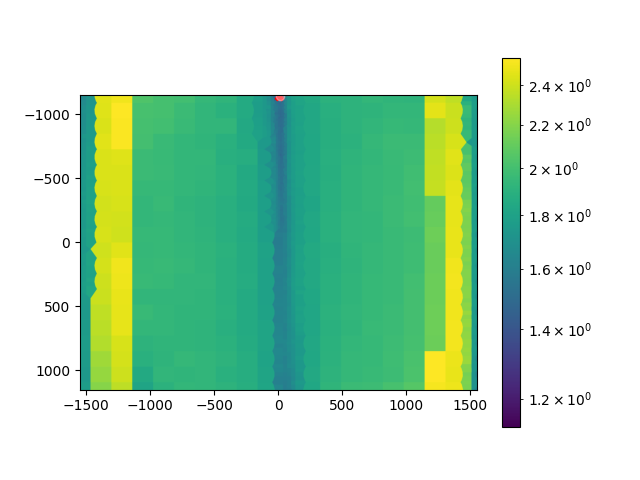

|    | reference                          |   total_checked |   total_time | reference_offset   | optimized_offset   |   optimized_metric |
|---:|:-----------------------------------|----------------:|-------------:|:-------------------|:-------------------|-------------------:|
|  0 | ('image_a02.jpg', 'image_a03.jpg') |            2153 |         15.3 | (8, -1146)         | (9, -1147)         |               1.13 |


In [24]:
# plt.close('all')
build_summary=list()
# full_relation=mis_project.get_relations()[3]
# for full_relation in mis_project.get_relations():
for full_relation in [mis_project.get_relations()[1]]:
    print(full_relation.get_reference())
    optimized_relation=dga.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            relation=full_relation,
            strategy=dga.strategy_scaled_grid,
            metric=dga.metric_squared_mean,
            strategy_max_size=20,
            strategy_grid_scale=1,
            filter=dga.filter_rgb_gray
            )["optimized_offset"]
    start_time=timeit.default_timer()
    full_dga_results=dga.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            # relation=full_relation,
            relation=MISRelationRectangular(image_pair=full_relation.get_reference(),rectangular=optimized_relation), #optimized relation
            strategy=dga.strategy_full_search_grid,
            # metric=dga.metric_combined_balanced,
            metric=metric_custom,
            filter=dga.filter_rgb_gray,
            strategy_edge_avoid=50,
            strategy_full_search_progression=[
                dict(quantile=0.1,spacing=32,), #number=100
                dict(quantile=0.01,spacing=16,), #number=200
                dict(quantile=0.001,spacing=8,), #number=400
                dict(quantile=0.0001,spacing=4,), #number=800
                dict(compare=1.2), #number=800
                dict(quantile=0.05,skeleton=True,),
                dict(quantile=0.0001,spacing=4,), #number=800
                dict(compare=1.2), #number=800
                dict(quantile=0.05,spacing=16,), #number=200
                dict(quantile=0.005,spacing=8,), #number=400
                dict(quantile=0.0005,spacing=4,), #number=800
                dict(compare=1.2), #number=800
                dict(quantile=0.001,spacing=4,check_all=10000), #number=800
                ],
            )
    end_time=timeit.default_timer()
    print(f"Reference Optimized: {optimized_relation} Full Search DGA Optimized: {full_dga_results["optimized_offset"]} Time: {end_time-start_time:0.1f}s")
    plt.figure()
    plt.imshow(
        X=full_dga_results["interp_results"],
        norm=colors.LogNorm(vmin=np.nanmin(full_dga_results["interp_results"]),
                            vmax=np.nanmax(full_dga_results["interp_results"])),
        extent=(np.min(full_dga_results["grid"][0])-0.5,
                np.max(full_dga_results["grid"][0])+0.5,
                np.max(full_dga_results["grid"][1])+0.5,
                np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
        )
    plt.colorbar()
    plt.scatter(*optimized_relation,marker="X",c='r')
    plt.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink',alpha=0.5)
    plt.show()
    build_summary.append({
        "reference":full_relation.get_reference(),
        "total_checked":np.sum(~np.isnan(full_dga_results["grid_results"])),
        "total_time":round(end_time-start_time,1),
        "reference_offset":optimized_relation,
        "optimized_offset":full_dga_results["optimized_offset"],
        "optimized_metric":round(np.nanmin(full_dga_results["grid_results"]),2),
        })
print(pd.DataFrame(build_summary).to_markdown())

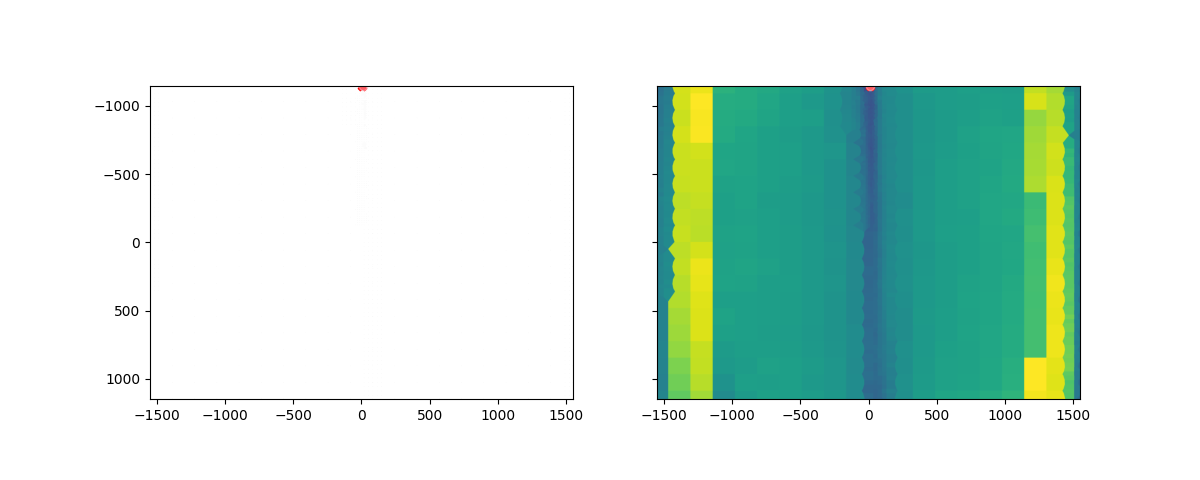

In [25]:
fig, (ax1,ax2)=plt.subplots(1,2,sharex=True,sharey=True)

ax1.imshow(full_dga_results["grid_results"],
        extent=(np.min(full_dga_results["grid"][0])-0.5,
                np.max(full_dga_results["grid"][0])+0.5,
                np.max(full_dga_results["grid"][1])+0.5,
                np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
                )

ax1.scatter(*optimized_relation,marker="X",c='r')
ax1.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink',alpha=0.5)

ax2.imshow(full_dga_results["interp_results"],
        extent=(np.min(full_dga_results["grid"][0])-0.5,
                np.max(full_dga_results["grid"][0])+0.5,
                np.max(full_dga_results["grid"][1])+0.5,
                np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
                )

ax2.scatter(*optimized_relation,marker="X",c='r')
ax2.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink',alpha=0.5)

fig.set_figwidth(12)
plt.show()

In [8]:
from skimage.morphology import skeletonize, dilation, footprints
from skimage.filters import gaussian

<Figure size 640x480 with 0 Axes>

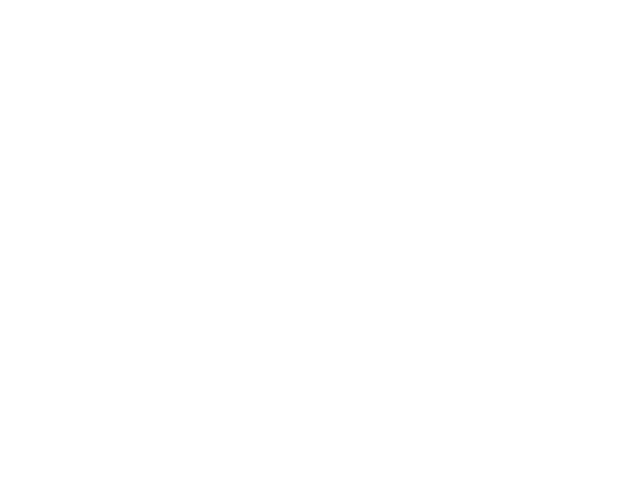

In [9]:
plt.figure()

In [10]:
# skeletonize((full_dga_results["interp_results"]<1.69))
quant=np.quantile(full_dga_results["interp_results"],q=0.05)
# binary=full_dga_results["interp_results"]<quant
binary=gaussian(full_dga_results["interp_results"],sigma=10)<quant
# binary=dilation(binary,footprint_rectangle((50,50)))
skeleton=skeletonize(binary)
expanded_skeleton=dilation(skeleton,footprints.disk(5))
plt.imshow(
    # X=skeleton,
    X=full_dga_results["grid_results"],
    # X=expanded_skeleton,
    # X=np.ma.masked_array(skeleton,skeleton),
    extent=(np.min(full_dga_results["grid"][0])-0.5,
                np.max(full_dga_results["grid"][0])+0.5,
                np.max(full_dga_results["grid"][1])+0.5,
                np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
                )
plt.scatter(*optimized_relation,marker="X",c='r')
plt.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink',alpha=0.5)
np.sum(expanded_skeleton)

np.int64(29333)

# Plotting visualizations of full search

In [94]:
# for full_relation in mis_project.get_relations():
for full_relation in [mis_project.get_relations()[7]]:
    print(full_relation.get_reference())
    optimized_relation=dga.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            relation=full_relation,
            strategy=dga.strategy_scaled_grid,
            metric=dga.metric_squared_mean,
            strategy_max_size=20,
            strategy_grid_scale=1,
            filter=dga.filter_rgb_gray
            )["optimized_offset"]
    start_time=timeit.default_timer()
    full_dga_results=dga.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            # relation=full_relation,
            relation=MISRelationRectangular(image_pair=full_relation.get_reference(),rectangular=optimized_relation), #optimized relation
            strategy=dga.strategy_full_search_grid,
            metric=dga.metric_combined_balanced,
            filter=dga.filter_rgb_gray,
            strategy_edge_avoid=50,
            )
    end_time=timeit.default_timer()
    print(f"Reference Optimized: {optimized_relation} Full Search DGA Optimized: {full_dga_results["optimized_offset"]} Time: {end_time-start_time:0.1f}s")
    # plt.figure()
    # plt.imshow(
    #     X=full_dga_results["interp_results"],
    #     norm=colors.LogNorm(vmin=np.nanmin(full_dga_results["interp_results"]),
    #                         vmax=np.nanmax(full_dga_results["interp_results"])),
    #     extent=(np.min(full_dga_results["grid"][0])-0.5,
    #             np.max(full_dga_results["grid"][0])+0.5,
    #             np.max(full_dga_results["grid"][1])+0.5,
    #             np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
    #     )
    # plt.colorbar()
    # plt.scatter(*optimized_relation,marker="X",c='r')
    # plt.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink',alpha=0.5)
    # plt.show()

('image_a08.jpg', 'image_a09.jpg')
INFO:root:Initial Number: 20 Checking: 400 / 7,124,601
INFO:root:Quantile: 0.1/1.628 Spacing: 32 Checking: 700 / 729,712
INFO:root:Quantile: 0.01/1.442 Spacing: 16 Checking: 180 / 71,233
INFO:root:Quantile: 0.001/1.293 Spacing: 8 Checking: 83 / 7,317
INFO:root:Quantile: 0.0001/1.223 - Checking all: 707 / 707
INFO:root:Metric: 1.179 is above threshold 1 - Continuing.
INFO:root:Quantile: 0.05/1.586 - Skeleton - Checking: 846 / 7,686
INFO:root:Quantile: 0.0001/1.222 - Checking all: 290 / 290
INFO:root:Metric: 0.915 is below threshold 1 - Stopping.
INFO:root:Optimized metric: 0.915
Reference Optimized: (8, -938) Full Search DGA Optimized: (8, -938) Time: 42.8s


In [ ]:
# plt.close('all')

In [95]:
from matplotlib.patches import Rectangle

Reference Optimized: (8, -938) Full Search DGA Optimized: (8, -938) Time: 42.8s


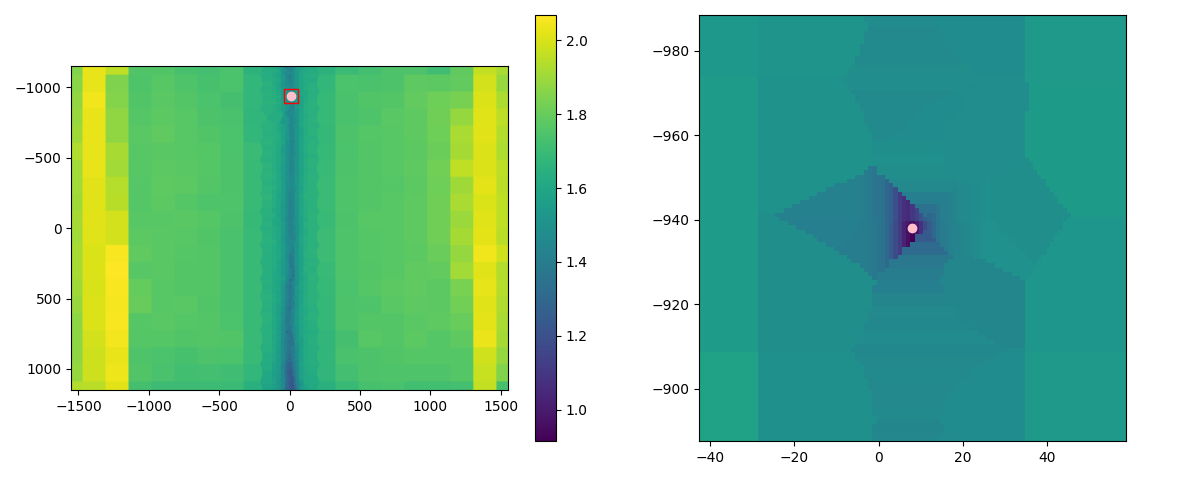

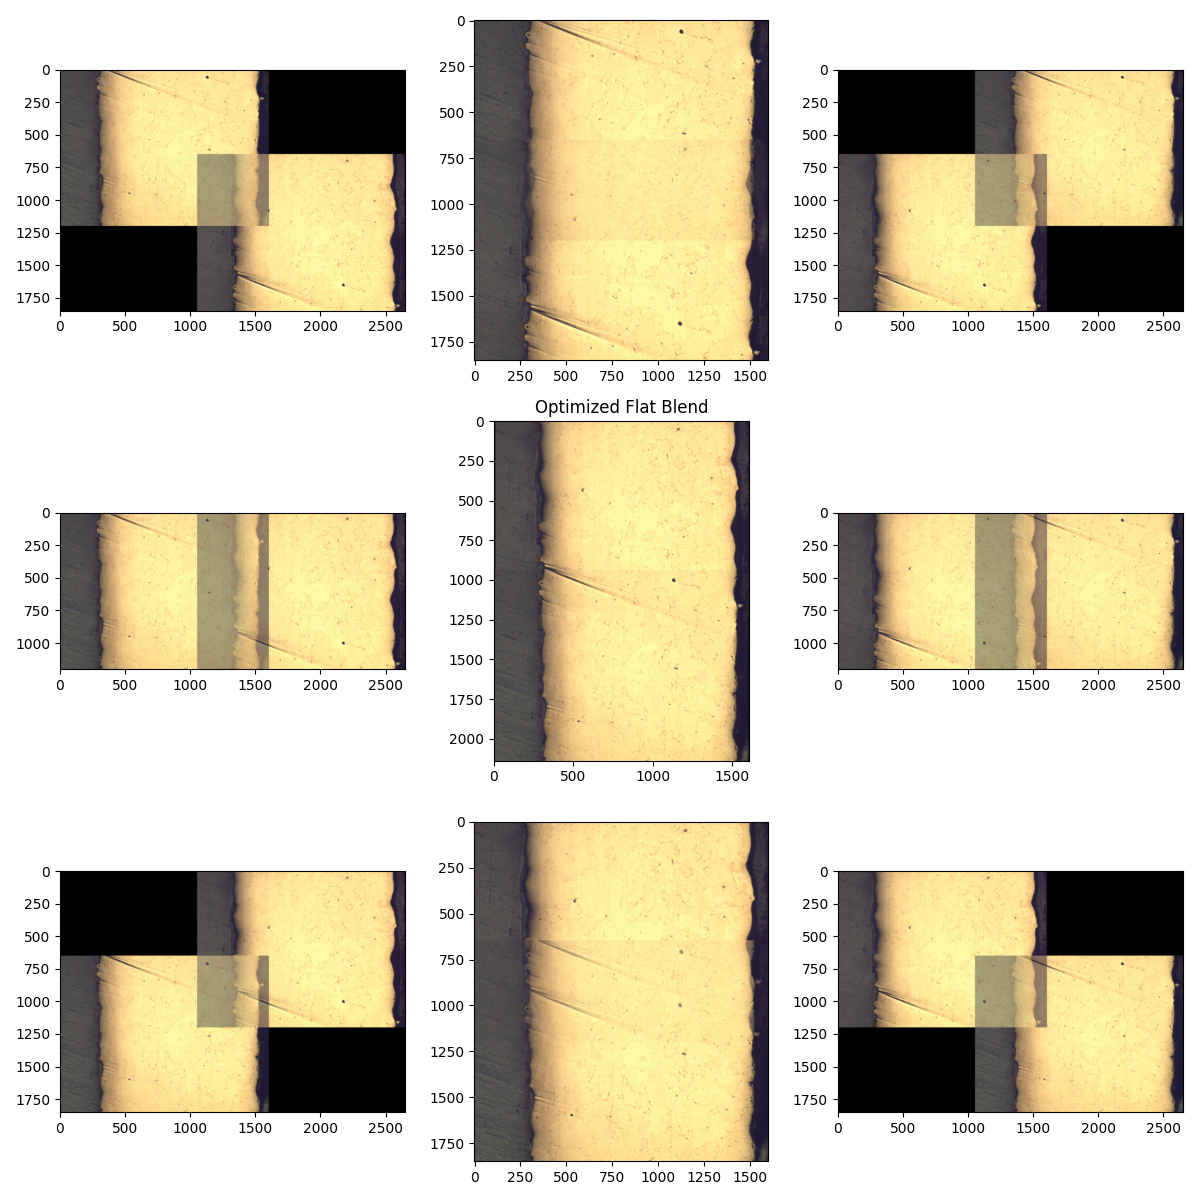

In [96]:
print(f"Reference Optimized: {optimized_relation} Full Search DGA Optimized: {full_dga_results["optimized_offset"]} Time: {end_time-start_time:0.1f}s")
fig1,(ax1,ax2)=plt.subplots(nrows=1,ncols=2)
ax1:plt.Axes
ax2:plt.Axes

focus=101

im1=ax1.imshow(
    X=full_dga_results["interp_results"],
    extent=(np.min(full_dga_results["grid"][0])-0.5,
            np.max(full_dga_results["grid"][0])+0.5,
            np.max(full_dga_results["grid"][1])+0.5,
            np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
    )
cb1=plt.colorbar(mappable=im1)
# ax1.scatter(*optimized_relation,marker="X",c='r')
ax1.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink')

ax1.add_artist(
    Rectangle(
        xy=(optimized_relation[0]-focus/2,optimized_relation[1]-focus/2),
        width=focus,
        height=focus,facecolor="none", edgecolor='r'),
    )

im2=ax2.imshow(
    X=full_dga_results["interp_results"],
    extent=(np.min(full_dga_results["grid"][0])-0.5,
            np.max(full_dga_results["grid"][0])+0.5,
            np.max(full_dga_results["grid"][1])+0.5,
            np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
    )
# cb2=plt.colorbar(mappable=im2)
# ax2.scatter(*optimized_relation,marker="X",c='r')
ax2.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink')
ax2.set_xlim(left=optimized_relation[0]-focus/2,right=optimized_relation[0]+focus/2)
ax2.set_ylim(top=optimized_relation[1]-focus/2,bottom=optimized_relation[1]+focus/2)

fig1.set_figwidth(12)
plt.tight_layout()
plt.show()

inset=500

mosaic=[["tl","tc","tr"],["ml","mc","mr"],["bl","bc","br"]]
fig2,axs=plt.subplot_mosaic(mosaic=mosaic) # top/middle/bottom - left/right/center

for row in mosaic:
    for position in row:
        if position=="mc":
            offset=full_dga_results["optimized_offset"]
        else:
            match position[0]:
                case "t":
                    y_index=-inset
                case "m":
                    y_index=int(full_dga_results["grid_results"].shape[0]/2)
                case "b":
                    y_index=+inset
            match position[1]:
                case "l":
                    x_index=-inset
                case "c":
                    x_index=int(full_dga_results["grid_results"].shape[1]/2)
                case "r":
                    x_index=inset
            offset=tuple(full_dga_results["grid"][:,y_index,x_index].tolist())
            ax1.scatter(offset[0],offset[1],marker="s",c="k")
        # print(offset)
        plt.sca(axs[position])
        if position=="mc":
            plt.title("Optimized Flat Blend")
        dga.plot_rectangular_pair(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            relation=offset,
            weight=cr.weight_flat,
            focus_overlap=False,
            )
fig2.set_figwidth(12)
fig2.set_figheight(12)
plt.tight_layout()
plt.show()


# Metric testing

In [ ]:
# def metric_highlow_inverse_norm_test(overlap_a:np.ndarray,overlap_b:np.ndarray,modifier=64)->float:
#     """High value when difference of maximum and minimum intensity of overlap region is low > weights against low-feature regions"""
#     def metric(overlap):
#         return  np.min([1/((np.max(overlap)-np.min(overlap))/modifier),1])
#         # variation of 64 > value of 1 > variation of 128 > value of 1/2
#     return np.max([metric(overlap_a),metric(overlap_b)])

# def metric_custom(overlap_a:np.ndarray,overlap_b:np.ndarray):
#     return np.sum([
#         dga.metric_difference_max_norm(overlap_a,overlap_b),
#         dga.metric_squared_mean_norm(overlap_a,overlap_b)**0.1,
#         # dga.metric_highlow_inverse_norm(overlap_a,overlap_b),
#         metric_highlow_inverse_norm_test(overlap_a,overlap_b),
#     ])
# def metric_square_modified(overlap_a:np.ndarray,overlap_b:np.ndarray):
#     return dga.metric_squared_mean_norm(overlap_a,overlap_b)**0.1

metric_highlow_inverse_norm
(9, -1147) : 0.08376963350785341
(-1212, 985) : 0.22857142857142856
(-1500, -700) : 0.4
metric_highlow_inverse_norm_test
(9, -1147) : 0.33507853403141363
(-1212, 985) : 0.9142857142857143
(-1500, -700) : 1.0
metric_difference_max_norm
(9, -1147) : 0.21176470588235294
(-1212, 985) : 0.6039215686274509
(-1500, -700) : 0.17647058823529413
metric_custom
(9, -1147) : 1.1263996276437553
(-1212, 985) : 2.329367976155917
(-1500, -700) : 1.7559691474863106
(9, -1147)


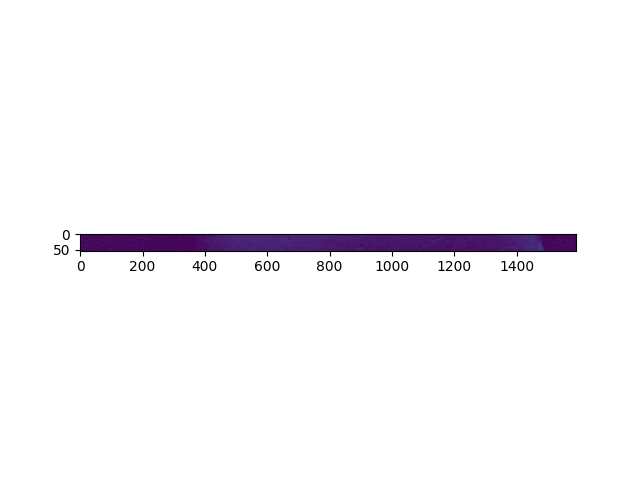

(-1212, 985)


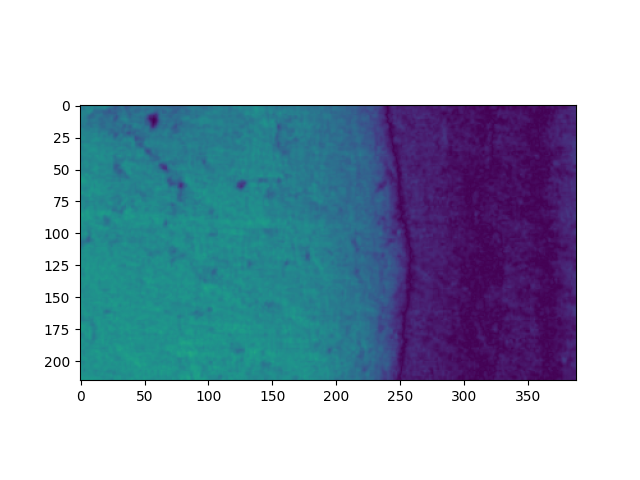

(-1500, -700)


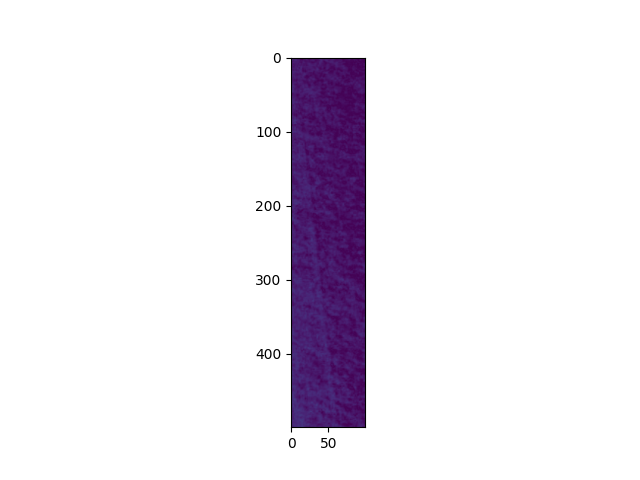

In [26]:
test_relation=mis_project.get_relations()[1]
metric_functions=[dga.metric_highlow_inverse_norm,metric_highlow_inverse_norm_test,dga.metric_difference_max_norm,metric_custom]
offsets=[(9, -1147),(-1212, 985),(-1500,-700)]
for metric_function in metric_functions:
    print(metric_function.__name__)
    for offset in offsets:
        # print(offset)
        metric,difference=dga.overlap_compare(
                image_a_array=dga.filter_rgb_gray(mis_project.get_image(test_relation.get_reference()[0])),
                image_b_array=dga.filter_rgb_gray(mis_project.get_image(test_relation.get_reference()[1])),
                offset_ab=offset,
                metric=metric_function,#metric_combined_adjusted,
                return_difference=True
                )  # ty:ignore[not-iterable]
        print(offset,":",metric)
for offset in offsets:
    metric,difference=dga.overlap_compare(
            image_a_array=dga.filter_rgb_gray(mis_project.get_image(test_relation.get_reference()[0])),
            image_b_array=dga.filter_rgb_gray(mis_project.get_image(test_relation.get_reference()[1])),
            offset_ab=offset,
            metric=lambda a,b:0,#metric_combined_adjusted,
            return_difference=True
            )  # ty:ignore[not-iterable]
    print(offset)
    plt.figure()
    plt.imshow(np.abs(difference),vmin=0,vmax=255)
    plt.show()